In [1]:
from pathlib import Path
import pandas as pd

data_dir = Path(".")
if not (data_dir / "customer_orders.csv").exists():
    data_dir = Path("BIG DATA/DaniPizza")

customer_orders = pd.read_csv(data_dir / "customer_orders.csv")
pizza_names = pd.read_csv(data_dir / "pizza_names.csv")
pizza_recipes = pd.read_csv(data_dir / "pizza_recipes.csv")
pizza_toppings = pd.read_csv(data_dir / "pizza_toppings.csv")
runners = pd.read_csv(data_dir / "runners.csv")
runner_orders = pd.read_csv(data_dir / "runner_orders.csv")

customer_orders.head()

,order_id,customer_id,pizza_id,exclusions,extras,order_date
0,2481,500,2,NaN,NaN,2025-02-21 16:06:46
1,1897,269,6,NaN,NaN,2025-08-12 08:27:50
2,1842,59,7,NaN,NaN,2024-12-23 20:50:23
3,1869,710,6,NaN,NaN,2025-01-31 09:16:49
4,2384,189,3,NaN,NaN,2024-11-30 17:35:37


In [2]:
import sqlite3

with sqlite3.connect(":memory:") as conn:
    customer_orders.to_sql("customer_orders", conn, index=False, if_exists="replace")
    pizza_names.to_sql("pizza_names", conn, index=False, if_exists="replace")

    query = """
    SELECT
        co.order_id,
        co.customer_id,
        co.pizza_id,
        pn.pizza_name,
        co.exclusions,
        co.extras,
        co.order_date
    FROM customer_orders AS co
    LEFT JOIN pizza_names AS pn
        ON co.pizza_id = pn.pizza_id
    """

    orders_with_pizza_names = pd.read_sql_query(query, conn)

orders_with_pizza_names.head()

,order_id,customer_id,pizza_id,pizza_name,exclusions,extras,order_date
0,2481,500,2,Vegetarian,None,None,2025-02-21 16:06:46
1,1897,269,6,Pepperoni,None,None,2025-08-12 08:27:50
2,1842,59,7,Vegan Veggie,None,None,2024-12-23 20:50:23
3,1869,710,6,Pepperoni,None,None,2025-01-31 09:16:49
4,2384,189,3,Meat Lovers,None,None,2024-11-30 17:35:37


# EDA

### Customer orders

In [3]:
customer_orders.info()
customer_orders.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2101 entries, 0 to 2100
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   order_id     2101 non-null   int64 
 1   customer_id  2101 non-null   int64 
 2   pizza_id     2101 non-null   int64 
 3   exclusions   629 non-null    object
 4   extras       666 non-null    object
 5   order_date   2101 non-null   object
dtypes: int64(3), object(3)
memory usage: 98.6+ KB


,order_id,customer_id,pizza_id
count,2101.000000,2101.000000,2101.000000
mean,1755.314612,419.000000,3.834841
std,429.404435,240.507125,1.847996
min,1001.000000,1.000000,1.000000
25%,1390.000000,207.000000,2.000000
50%,1756.000000,453.000000,4.000000
75%,2122.000000,654.000000,6.000000
max,2500.000000,798.000000,7.000000


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

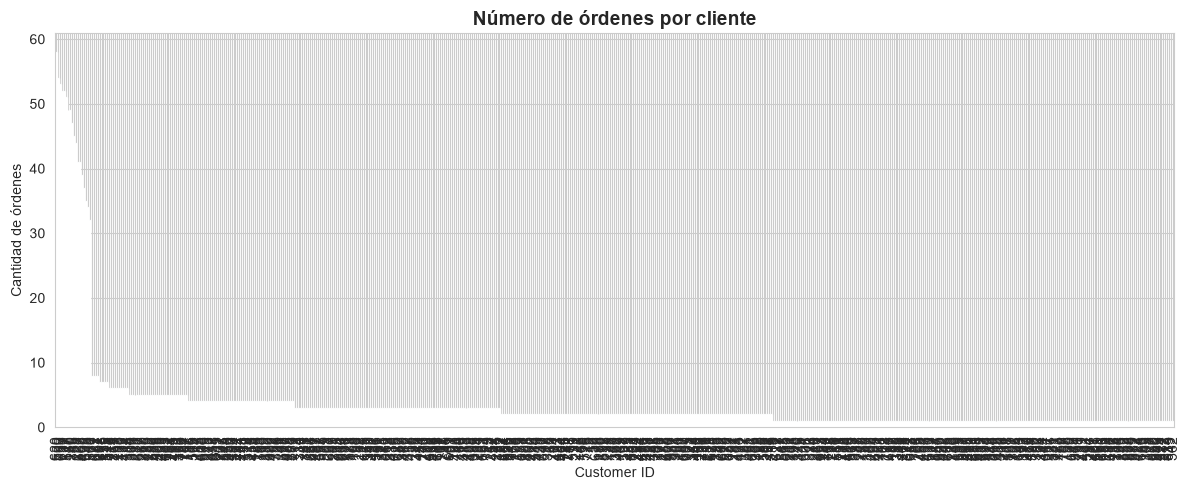

In [5]:
# 1. Órdenes por cliente
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
customer_orders['customer_id'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Número de órdenes por cliente', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer ID')
ax.set_ylabel('Cantidad de órdenes')
plt.tight_layout()
plt.show()

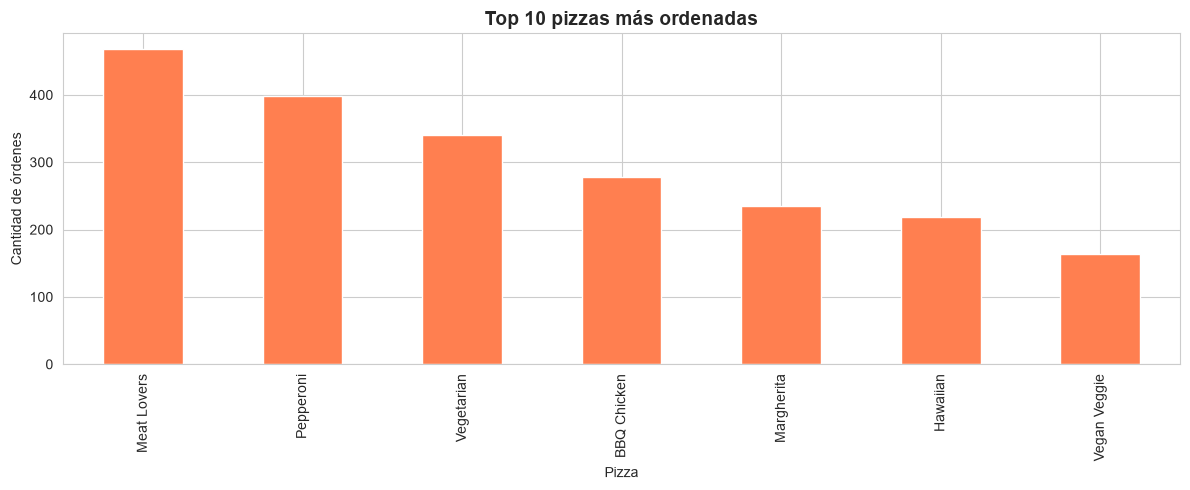

In [6]:
# 2. Pizzas más ordenadas
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
orders_with_pizza_names['pizza_name'].value_counts().head(10).plot(kind='bar', ax=ax, color='coral')
ax.set_title('Top 10 pizzas más ordenadas', fontsize=14, fontweight='bold')
ax.set_xlabel('Pizza')
ax.set_ylabel('Cantidad de órdenes')
plt.tight_layout()
plt.show()

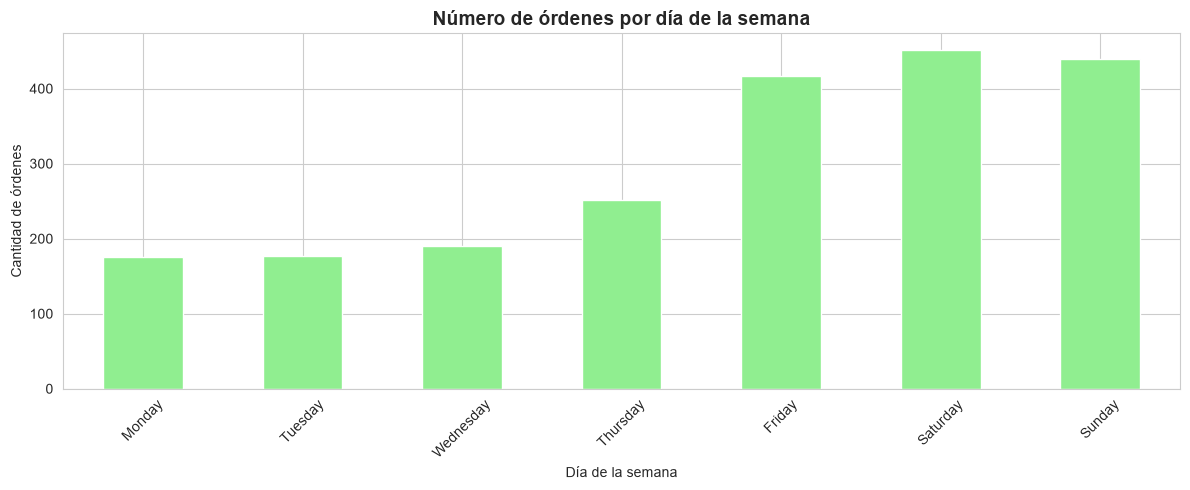

In [7]:
# 3. Órdenes por día de la semana
customer_orders['order_date'] = pd.to_datetime(customer_orders['order_date'])
customer_orders['day_of_week'] = customer_orders['order_date'].dt.day_name()

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orders_by_day = customer_orders['day_of_week'].value_counts().reindex(day_order)
orders_by_day.plot(kind='bar', ax=ax, color='lightgreen')
ax.set_title('Número de órdenes por día de la semana', fontsize=14, fontweight='bold')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Cantidad de órdenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

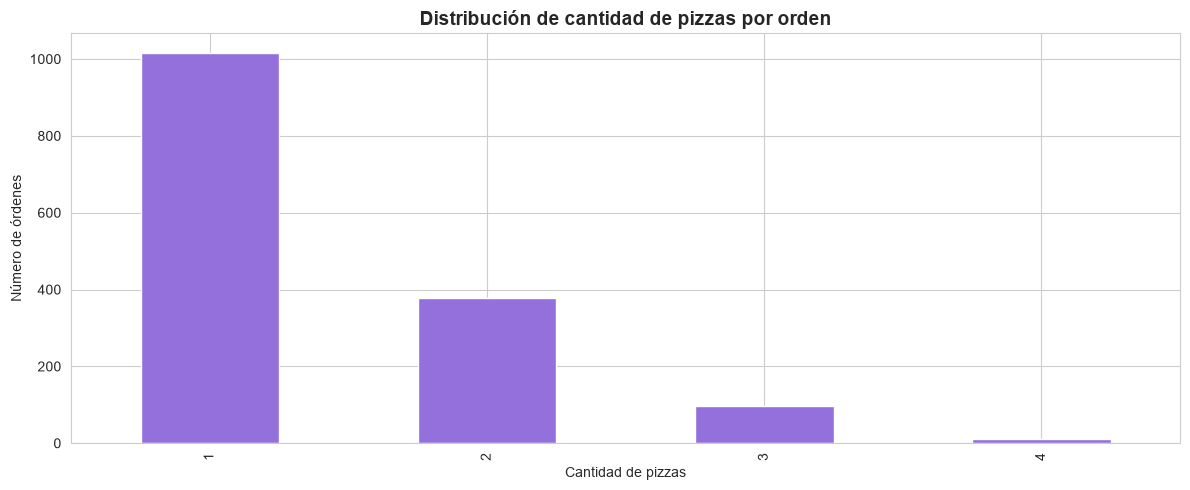

In [8]:
# 4. Distribución de cantidad de pizzas por orden
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
pizzas_por_orden = customer_orders.groupby('order_id').size()
pizzas_por_orden.value_counts().sort_index().plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Distribución de cantidad de pizzas por orden', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de pizzas')
ax.set_ylabel('Número de órdenes')
plt.tight_layout()
plt.show()

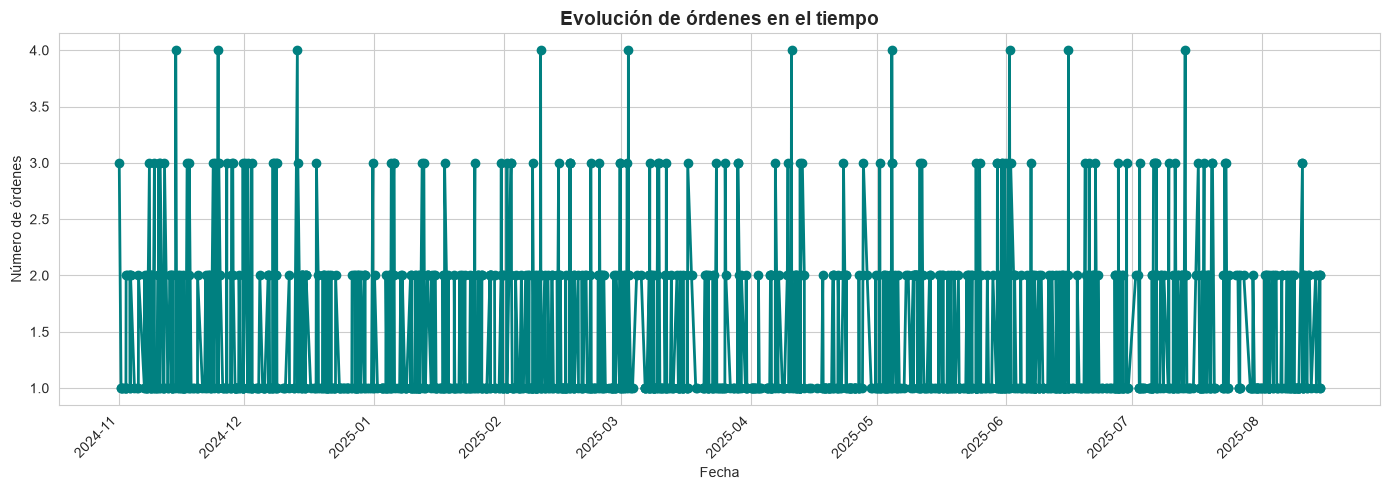

In [9]:
# 5. Órdenes por fecha (tendencia temporal)
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
orders_by_date = customer_orders.groupby('order_date').size()
orders_by_date.plot(ax=ax, color='teal', linewidth=2, marker='o')
ax.set_title('Evolución de órdenes en el tiempo', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de órdenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()